In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import warnings
from pathlib import Path
from scipy import stats

warnings.filterwarnings('ignore')

# ── Setup Directories ─────────────────────────────────────────────────────────
notebook_dir = Path.cwd()
root_dir = notebook_dir.parent if notebook_dir.name == 'notebook' else notebook_dir

DATA_PATH = root_dir / 'data' / 'genz_social_media_usage_1M.csv'
OUTPUT_DIR = root_dir / 'output'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Configure Styling ─────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='coolwarm', font_scale=1.1)
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#f8f9fa'
plt.rcParams['grid.alpha'] = 0.3
COLORS = sns.color_palette('coolwarm', 8)

print('='*70)
print('RQ2: Night Usage & Mental Health Score Analysis')
print('='*70)

RQ2: Night Usage & Mental Health Score Analysis


In [4]:
# ── Load and Validate Data ───────────────────────────────────────────────────

df = pd.read_csv('genz_social_media_usage_1Million.csv')
print(f'✅ Data loaded successfully')
print(f'   Shape: {df.shape}')
print(f'   Columns: {df.columns.tolist()}')
print(f'   Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')
    


✅ Data loaded successfully
   Shape: (1000000, 12)
   Columns: ['age', 'gender', 'country', 'daily_usage_hours', 'primary_platform', 'num_platforms_used', 'purpose', 'avg_session_minutes', 'night_usage', 'mental_health_score', 'addiction_level', 'screen_time_before_sleep']
   Memory usage: 318.74 MB


In [5]:
# ── Data Overview ────────────────────────────────────────────────────────────
print('\n📊 Data Overview')
print('-' * 70)

# Check for relevant columns
if 'night_usage' in df.columns and 'mental_health_score' in df.columns:
    print(f'✅ Required columns found')
    print(f'\n   Night Usage Categories: {sorted(df["night_usage"].unique())}')
    print(f'   Mental Health Score - Min: {df["mental_health_score"].min():.2f}, Max: {df["mental_health_score"].max():.2f}')
    print(f'   Total Records: {len(df):,}')
else:
    print('❌ Required columns missing')
    print(f'Available columns: {df.columns.tolist()}')
    raise ValueError('night_usage or mental_health_score column not found')


📊 Data Overview
----------------------------------------------------------------------
✅ Required columns found

   Night Usage Categories: [np.int64(0), np.int64(1)]
   Mental Health Score - Min: 1.00, Max: 10.00
   Total Records: 1,000,000


In [6]:
# ── Table 1: Summary Statistics by Night Usage ────────────────────────────
print('\n📋 TABLE 1: Summary Statistics by Night Usage')
print('=' * 70)

# Create comprehensive summary
summary_stats = df.groupby('night_usage')['mental_health_score'].agg([
    ('Count', 'count'),
    ('Mean', 'mean'),
    ('Median', 'median'),
    ('Std Dev', 'std'),
    ('Min', 'min'),
    ('Max', 'max'),
    ('Q1', lambda x: x.quantile(0.25)),
    ('Q3', lambda x: x.quantile(0.75))
]).round(2)

# Add percentage distribution
summary_stats['Percentage'] = (summary_stats['Count'] / summary_stats['Count'].sum() * 100).round(2)

# Reorder columns for better readability
summary_stats = summary_stats[['Count', 'Percentage', 'Mean', 'Median', 'Std Dev', 'Min', 'Q1', 'Q3', 'Max']]

print('\n' + summary_stats.to_string())
print('\n' + '-' * 70)

# Save table to CSV
csv_file = OUTPUT_DIR / 'RQ2_Summary_Table.csv'
summary_stats.to_csv(csv_file)
print(f'\n✅ Table saved to: {csv_file}')


📋 TABLE 1: Summary Statistics by Night Usage

              Count  Percentage  Mean  Median  Std Dev  Min    Q1    Q3   Max
night_usage                                                                  
0            400042        40.0  7.17     7.2      1.5  1.0  6.15  8.24  10.0
1            599958        60.0  7.17     7.2      1.5  1.0  6.15  8.24  10.0

----------------------------------------------------------------------

✅ Table saved to: C:\Users\patil\Downloads\output\RQ2_Summary_Table.csv



📈 Generating Figure 1: Mean Mental Health Score Bar Chart
✅ Figure 1 saved to: C:\Users\patil\Downloads\output\Fig_1_Mean_MentalHealth_Bar.png


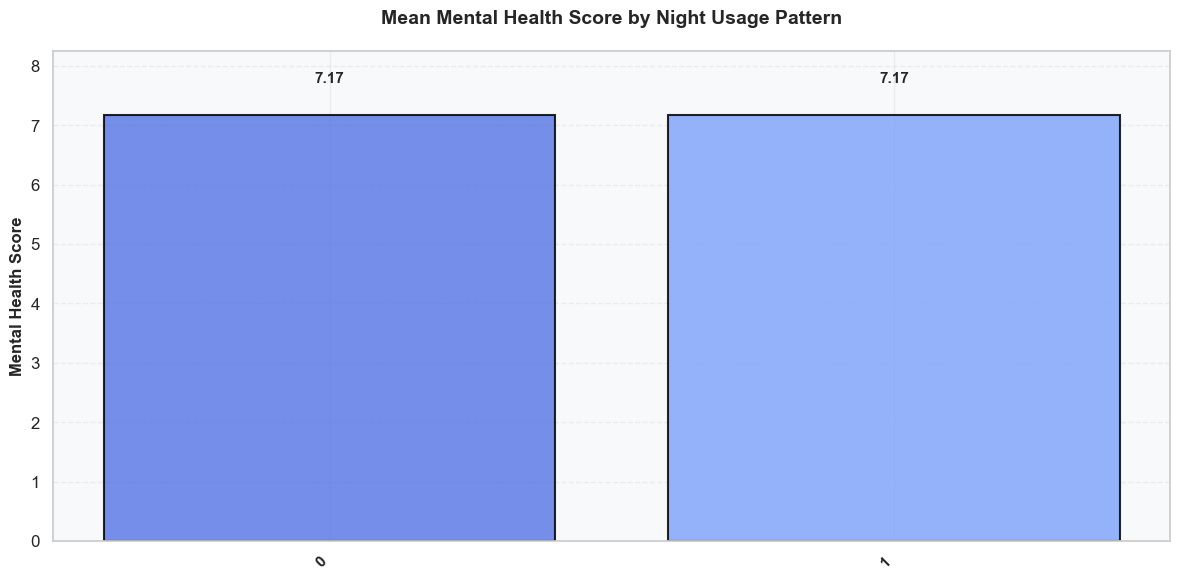

In [7]:
# ── Figure 1: Mean Mental Health Score by Night Usage (Bar Chart) ───────────
print('\n📈 Generating Figure 1: Mean Mental Health Score Bar Chart')

try:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Prepare data
    mean_data = summary_stats['Mean'].sort_values(ascending=False)
    
    # Create bar chart with gradient colors
    bars = ax.bar(range(len(mean_data)), mean_data.values, color=COLORS[:len(mean_data)], 
                  edgecolor='black', linewidth=1.5, alpha=0.85)
    
    # Add value labels on bars
    for idx, (bar, value) in enumerate(zip(bars, mean_data.values)):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{value:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    # Customize chart
    ax.set_xticks(range(len(mean_data)))
    ax.set_xticklabels(mean_data.index, fontsize=11, fontweight='bold', rotation=45, ha='right')
    ax.set_ylabel('Mental Health Score', fontsize=12, fontweight='bold')
    ax.set_title('Mean Mental Health Score by Night Usage Pattern', fontsize=14, fontweight='bold', pad=20)
    ax.set_ylim(0, mean_data.max() * 1.15)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    fig_file = OUTPUT_DIR / 'Fig_1_Mean_MentalHealth_Bar.png'
    fig.savefig(fig_file, dpi=300, bbox_inches='tight', facecolor='white')
    print(f'✅ Figure 1 saved to: {fig_file}')
    plt.show()
    
except Exception as e:
    print(f'❌ Error generating Figure 1: {e}')


📈 Generating Figure 2: Distribution Box Plot
✅ Figure 2 saved to: c:\Users\yashb\Downloads\Genz_socialmedia_ML\output\Fig_2_Distribution_Box.png


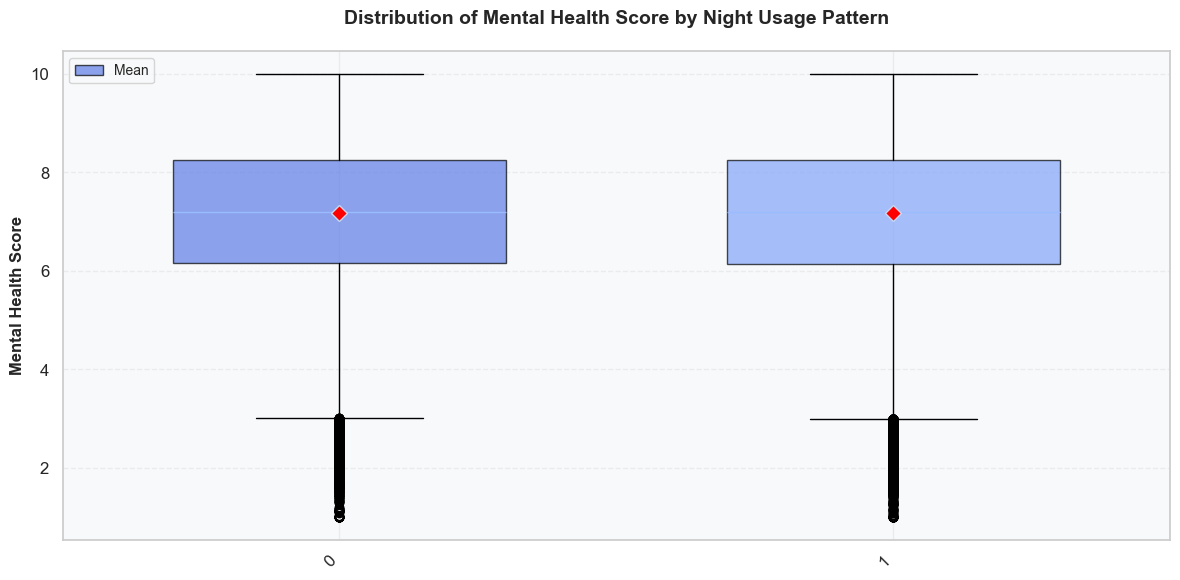

In [6]:
# ── Figure 2: Distribution of Mental Health Score by Night Usage (Box Plot) ─
print('\n📈 Generating Figure 2: Distribution Box Plot')

try:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Sort by median for better visualization
    night_order = df.groupby('night_usage')['mental_health_score'].median().sort_values(ascending=False).index
    
    # Create box plot
    bp = ax.boxplot([df[df['night_usage'] == level]['mental_health_score'].values 
                      for level in night_order],
                     labels=night_order,
                     patch_artist=True,
                     widths=0.6,
                     showmeans=True,
                     meanprops=dict(marker='D', markerfacecolor='red', markersize=8, label='Mean'))
    
    # Color the boxes
    for patch, color in zip(bp['boxes'], COLORS[:len(night_order)]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    # Customize
    ax.set_ylabel('Mental Health Score', fontsize=12, fontweight='bold')
    ax.set_title('Distribution of Mental Health Score by Night Usage Pattern', fontsize=14, fontweight='bold', pad=20)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.legend(['Mean'], loc='upper left', fontsize=10)
    plt.xticks(rotation=45, ha='right')
    
    plt.tight_layout()
    fig_file = OUTPUT_DIR / 'Fig_2_Distribution_Box.png'
    fig.savefig(fig_file, dpi=300, bbox_inches='tight', facecolor='white')
    print(f'✅ Figure 2 saved to: {fig_file}')
    plt.show()
    
except Exception as e:
    print(f'❌ Error generating Figure 2: {e}')


📈 Generating Figure 3: User Distribution Pie Chart
✅ Figure 3 saved to: C:\Users\patil\Downloads\output\Fig_3_Distribution_Pie.png


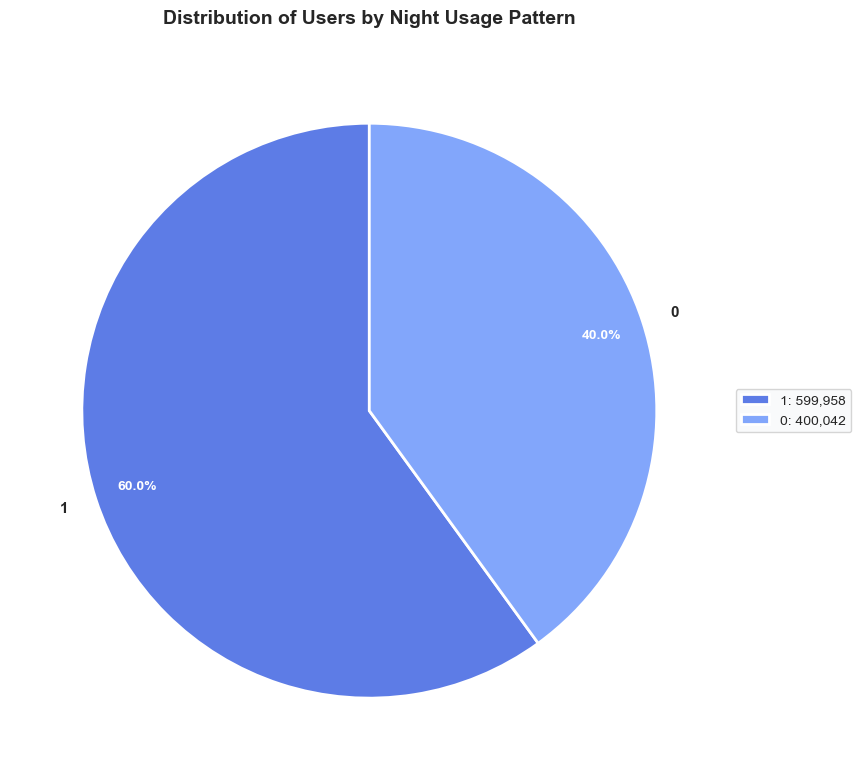

In [8]:
# ── Figure 3: User Distribution by Night Usage (Pie Chart) ───────────────────
print('\n📈 Generating Figure 3: User Distribution Pie Chart')

try:
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Prepare data
    night_counts = df['night_usage'].value_counts()
    
    # Create pie chart
    wedges, texts, autotexts = ax.pie(
        night_counts.values,
        labels=night_counts.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=COLORS[:len(night_counts)],
        wedgeprops=dict(edgecolor='white', linewidth=2),
        pctdistance=0.85,
        textprops={'fontsize': 11, 'fontweight': 'bold'}
    )
    
    # Customize percentage text
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontsize(10)
        autotext.set_fontweight('bold')
    
    # Add count in legend
    legend_labels = [f'{label}: {count:,}' for label, count in night_counts.items()]
    ax.legend(legend_labels, loc='center left', bbox_to_anchor=(1, 0, 0.5, 1), fontsize=10)
    
    ax.set_title('Distribution of Users by Night Usage Pattern', fontsize=14, fontweight='bold', pad=20)
    
    plt.tight_layout()
    fig_file = OUTPUT_DIR / 'Fig_3_Distribution_Pie.png'
    fig.savefig(fig_file, dpi=300, bbox_inches='tight', facecolor='white')
    print(f'✅ Figure 3 saved to: {fig_file}')
    plt.show()
    
except Exception as e:
    print(f'❌ Error generating Figure 3: {e}')


📈 Generating Figure 4: Violin Plot Comparison
✅ Figure 4 saved to: c:\Users\yashb\Downloads\Genz_socialmedia_ML\output\Fig_4_Violin_Distribution.png


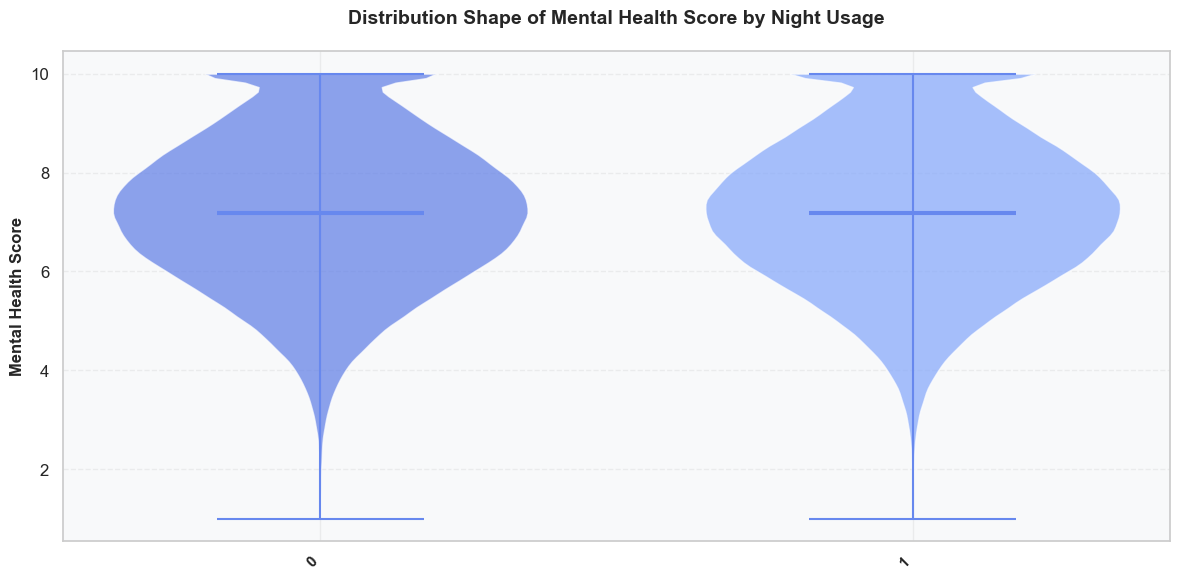

In [8]:
# ── Figure 4: Violin Plot (Distribution Comparison) ────────────────────────
print('\n📈 Generating Figure 4: Violin Plot Comparison')

try:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Prepare data for violin plot
    night_order = df.groupby('night_usage')['mental_health_score'].median().sort_values(ascending=False).index
    plot_data = df[['night_usage', 'mental_health_score']].copy()
    plot_data['night_usage'] = pd.Categorical(plot_data['night_usage'], categories=night_order, ordered=True)
    plot_data = plot_data.sort_values('night_usage')
    
    # Create violin plot
    parts = ax.violinplot([df[df['night_usage'] == level]['mental_health_score'].values 
                           for level in night_order],
                          positions=range(len(night_order)),
                          widths=0.7,
                          showmeans=True,
                          showmedians=True)
    
    # Color violins
    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(COLORS[i])
        pc.set_alpha(0.7)
    
    # Customize
    ax.set_xticks(range(len(night_order)))
    ax.set_xticklabels(night_order, fontsize=11, fontweight='bold', rotation=45, ha='right')
    ax.set_ylabel('Mental Health Score', fontsize=12, fontweight='bold')
    ax.set_title('Distribution Shape of Mental Health Score by Night Usage', fontsize=14, fontweight='bold', pad=20)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    fig_file = OUTPUT_DIR / 'Fig_4_Violin_Distribution.png'
    fig.savefig(fig_file, dpi=300, bbox_inches='tight', facecolor='white')
    print(f'✅ Figure 4 saved to: {fig_file}')
    plt.show()
    
except Exception as e:
    print(f'❌ Error generating Figure 4: {e}')

In [9]:
# ── Additional Statistics Table ───────────────────────────────────────────
print('\n📋 TABLE 2: Additional Statistical Measures')
print('=' * 70)

# Calculate skewness and kurtosis
additional_stats = []
for level in df['night_usage'].unique():
    data = df[df['night_usage'] == level]['mental_health_score']
    additional_stats.append({
        'Night Usage': level,
        'Skewness': stats.skew(data),
        'Kurtosis': stats.kurtosis(data),
        'Variance': data.var(),
        'IQR': data.quantile(0.75) - data.quantile(0.25)
    })

additional_df = pd.DataFrame(additional_stats).set_index('Night Usage').round(4)
print('\n' + additional_df.to_string())
print('\n' + '-' * 70)

# Save additional stats
stats_file = OUTPUT_DIR / 'RQ2_Additional_Statistics.csv'
additional_df.to_csv(stats_file)
print(f'\n✅ Additional statistics saved to: {stats_file}')


📋 TABLE 2: Additional Statistical Measures

             Skewness  Kurtosis  Variance     IQR
Night Usage                                      
0             -0.1950   -0.2931    2.2637  2.0955
1             -0.1906   -0.2996    2.2603  2.0972

----------------------------------------------------------------------

✅ Additional statistics saved to: C:\Users\patil\Downloads\output\RQ2_Additional_Statistics.csv


In [10]:
# ── Final Summary Report ──────────────────────────────────────────────────
print('\n' + '='*70)
print('✅ ANALYSIS COMPLETE - SUMMARY REPORT')
print('='*70)

print(f'\n📊 Key Findings:')
print('-' * 70)

# Find highest and lowest mean mental health score
highest_night = summary_stats['Mean'].idxmax()
lowest_night = summary_stats['Mean'].idxmin()
highest_mean = summary_stats['Mean'].max()
lowest_mean = summary_stats['Mean'].min()

print(f'\n✓ Highest mean mental health score: {highest_night} ({highest_mean:.2f})')
print(f'✓ Lowest mean mental health score: {lowest_night} ({lowest_mean:.2f})')
print(f'✓ Difference: {highest_mean - lowest_mean:.2f} points')

print(f'\n📈 Distribution:')
for level in df['night_usage'].unique():
    count = summary_stats.loc[level, 'Count']
    pct = summary_stats.loc[level, 'Percentage']
    mean_score = summary_stats.loc[level, 'Mean']
    print(f'   • {level}: {int(count):,} users ({pct:.1f}%) - Avg score: {mean_score:.2f}')

print(f'\n📁 Output Files Generated:')
print('-' * 70)
print(f'   Tables:')
print(f'   • RQ2_Summary_Table.csv')
print(f'   • RQ2_Additional_Statistics.csv')
print(f'\n   Figures:')
print(f'   • Fig_1_Mean_MentalHealth_Bar.png')
print(f'   • Fig_2_Distribution_Box.png')
print(f'   • Fig_3_Distribution_Pie.png')
print(f'   • Fig_4_Violin_Distribution.png')
print(f'\n📂 All outputs saved to: {OUTPUT_DIR}')
print(f'\n' + '='*70)


✅ ANALYSIS COMPLETE - SUMMARY REPORT

📊 Key Findings:
----------------------------------------------------------------------

✓ Highest mean mental health score: 0 (7.17)
✓ Lowest mean mental health score: 0 (7.17)
✓ Difference: 0.00 points

📈 Distribution:
   • 0: 400,042 users (40.0%) - Avg score: 7.17
   • 1: 599,958 users (60.0%) - Avg score: 7.17

📁 Output Files Generated:
----------------------------------------------------------------------
   Tables:
   • RQ2_Summary_Table.csv
   • RQ2_Additional_Statistics.csv

   Figures:
   • Fig_1_Mean_MentalHealth_Bar.png
   • Fig_2_Distribution_Box.png
   • Fig_3_Distribution_Pie.png
   • Fig_4_Violin_Distribution.png

📂 All outputs saved to: C:\Users\patil\Downloads\output

